In [88]:
!pip install pyodbc
!pip install pandas
!pip install scikit-learn
!apt install unixodbc -y


[notice] A new release of pip is available: 23.1.2 -> 23.3
[notice] To update, run: python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 23.1.2 -> 23.3
[notice] To update, run: python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 23.1.2 -> 23.3
[notice] To update, run: python3 -m pip install --upgrade pip
Reading package lists... Done
Building dependency tree       
Reading state information... Done
The following additional packages will be installed:
  libltdl7 libodbc1 odbcinst odbcinst1debian2
Suggested packages:
  libmyodbc odbc-postgresql tdsodbc unixodbc-bin
The following NEW packages will be installed:
  libltdl7 libodbc1 odbcinst odbcinst1debian2 unixodbc
0 upgraded, 5 newly installed, 0 to remove and 14 not upgraded.
Need to get 309 kB of archives.
After this operation, 1521 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu focal/main amd64 libltdl7 amd64 2.4.6-14 [38.5 kB]
Get:2 http://a

In [18]:
import pyodbc
import pandas as pd
import csv

# Konfiguracja połączenia zapisana w formie słownika
connection_config = {
    'server': 'analityk.wwsi.edu.pl,50221',
    'database': 'synop',
    'user': 'student',
    'password': 'ciekawski',
    'encrypt': 'yes',  # Lub 'no', w zależności od konfiguracji serwera
    'trust_server_certificate': 'yes',  # Lub 'no', w zależności od konfiguracji serwera
    'driver': '{ODBC Driver 18 for SQL Server}',  # To jest nazwa sterownika ODBC
    'autocommit': True  # Opcjonalnie, jeśli chcesz włączyć tryb autocommit
}

# Tworzenie łańcucha połączenia z konfiguracji
connection_string = (
    f"DRIVER={connection_config['driver']};"
    f"SERVER={connection_config['server']};"
    f"DATABASE={connection_config['database']};"
    f"UID={connection_config['user']};"
    f"PWD={connection_config['password']};"
    f"Encrypt={connection_config['encrypt']};"
    f"TrustServerCertificate={connection_config['trust_server_certificate']};"
)

try:
    # Nawiązanie połączenia
    conn = pyodbc.connect(connection_string)

    # Wykonanie operacji na bazie danych
    cursor = conn.cursor()
    cursor.execute("SELECT * FROM [Synop].[dbo].[DaneModelTMP]")
    rows = cursor.fetchall()
    # for row in rows:
    # Zapisz wyniki do pliku CSV

    with open('DaneModelTMP.csv_', 'w', newline='') as csv_file:
        csv_writer = csv.writer(csv_file)
        csv_writer.writerow([i[0] for i in cursor.description])  # Nagłówki kolumn
        csv_writer.writerows(rows)  # Dane

except pyodbc.Error as ex:
    print(f"Błąd połączenia: {ex}")

finally:
    if 'conn' in locals():
        conn.close()

In [2]:
import pyodbc
import pandas as pd
import csv

# Konfiguracja połączenia zapisana w formie słownika
connection_config = {
    'server': 'analityk.wwsi.edu.pl,50221',
    'database': 'synop',
    'user': 'student',
    'password': 'ciekawski',
    'encrypt': 'yes',  # Lub 'no', w zależności od konfiguracji serwera
    'trust_server_certificate': 'yes',  # Lub 'no', w zależności od konfiguracji serwera
    'driver': '{ODBC Driver 18 for SQL Server}',  # To jest nazwa sterownika ODBC
    'autocommit': True  # Opcjonalnie, jeśli chcesz włączyć tryb autocommit
}

# Tworzenie łańcucha połączenia z konfiguracji
connection_string = (
    f"DRIVER={connection_config['driver']};"
    f"SERVER={connection_config['server']};"
    f"DATABASE={connection_config['database']};"
    f"UID={connection_config['user']};"
    f"PWD={connection_config['password']};"
    f"Encrypt={connection_config['encrypt']};"
    f"TrustServerCertificate={connection_config['trust_server_certificate']};"
)

# Nawiązanie połączenia
conn = pyodbc.connect(connection_string)

# Wykonanie operacji na bazie danych
#cursor = conn.cursor()
#    cursor.execute("SELECT * FROM [Synop].[dbo].[DaneModelTMP] Where Pred6 > -1 and data > '20000101'")
#    rows = cursor.fetchall()
    # for row in rows:
query = "SELECT * FROM [Synop].[dbo].[DaneModelTMP] Where Pred6 > -1 and data > '20000101'"
df = pd.read_sql(query, conn)
    # Zapisz wyniki do pliku CSV
print(df.head())
conn.close()

                 czas        data  Pora  miesiac  Widz3  Widz6    Zachm3  \
0 2013-08-06 04:00:00  2013-08-06     1        8  30000  30000  0.000000   
1 2013-08-06 08:00:00  2013-08-06     2        8  20000  23333  1.000000   
2 2013-08-06 12:00:00  2013-08-06     3        8  30000  26666  2.333333   
3 2013-08-06 16:00:00  2013-08-06     4        8  30000  30000  2.666666   
4 2013-08-06 20:00:00  2013-08-06     5        8  30000  30000  2.000000   

     Zachm6   ZachmN3   ZachmN6  ... OpadM_E OpadM_N OpadM_S Przelotny_W  \
0  0.000000  0.000000  0.000000  ...       0       0       0           0   
1  0.500000  0.000000  0.000000  ...       0       0       0           0   
2  1.833333  1.333333  0.833333  ...       0       0       0           0   
3  2.666666  1.666666  1.666666  ...       0       0       0           0   
4  2.166666  1.000000  1.166666  ...       0       0       0           0   

   Przelotny_E  Przelotny_N  Przelotny_S  Pred3  Pred6   id  
0            0          

In [1]:
import warnings
import pandas as pd
from io import StringIO
warnings.filterwarnings("ignore", category=pd.errors.DtypeWarning)
df = pd.read_csv('DaneModelTMP.csv', delimiter=',')

In [2]:
df.isnull()

,czas,data,Pora,miesiac,Widz3,Widz6,Zachm3,Zachm6,ZachmN3,ZachmN6,...,OpadM_E,OpadM_N,OpadM_S,Przelotny_W,Przelotny_E,Przelotny_N,Przelotny_S,Pred3,Pred6,id
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152765,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
152766,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
152767,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
152768,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [5]:
#!pip install sqlalchemy

In [6]:
df.shape

(152770, 62)

In [7]:
df.Widz3

0         30000
1         20000
2         30000
3         30000
4         30000
          ...  
152765     2266
152766     2533
152767     2800
152768     2500
152769     1900
Name: Widz3, Length: 152770, dtype: int64

In [8]:
df.drop(['Pred3'], axis=1, inplace=True)

In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Załadowanie zbioru danych
list_col = list(df.columns.values)

X, y = df[['Pora', 'Zachm3', \
       'Zachm6', 'ZachmN3', 'ZachmN6', 'Wiatr_N', 'Wiatr_E', 'Wiatr_S', \
       'Wiatr_W', 'DeltaTemp3', 'TemperaturaPowietrza', 'DeltaTemp6', \
       'DeltaTempRosy3', 'DeltaTempRosy6', 'TemperaturaPunktuRosy', \
       'Cisn3', 'Cisn6', 'CisnienieNaPoziomieStacji', 'Opady6', 'Opady12', \
       'Mgla6', 'Mzawka6', 'Deszcz6', 'Snieg6', 'Przelotny6', 'Burza6', \
       'Mgla_W', 'Mgla_E', 'Mgla_N', 'Mgla_S', 'Mzawka_W', 'Mzawka_E', \
       'Mzawka_N', 'Mzawka_S', 'Burza_W', 'Burza_E', 'Burza_N', 'Burza_S', \
       'Deszcz_W', 'Deszcz_E', 'Deszcz_N', 'Deszcz_S', 'Snieg_W', \
       'Snieg_E', 'Snieg_N', 'Snieg_S', 'OpadM_W', 'OpadM_E', 'OpadM_N', \
       'OpadM_S', 'Przelotny_W', 'Przelotny_E', 'Przelotny_N', \
       'Przelotny_S']], df.Pred6

# Podziel dane na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inicjalizuj model k-NN z 3 sąsiadami
knn = KNeighborsClassifier(n_neighbors=3)

# Trenuj model na danych treningowych
knn.fit(X_train, y_train)

# Przewiduj klasy na danych testowych
y_pred = knn.predict(X_test)

# Oblicz dokładność modelu
accuracy = accuracy_score(y_test, y_pred)
print("Dokładność modelu: {:.2f}".format(accuracy))


Dokładność modelu: 0.80


Testujemy model z 1 sąsiadami
Testujemy model z 2 sąsiadami
Testujemy model z 3 sąsiadami
Testujemy model z 4 sąsiadami
Testujemy model z 5 sąsiadami
Testujemy model z 6 sąsiadami
Testujemy model z 7 sąsiadami
Testujemy model z 8 sąsiadami
Testujemy model z 9 sąsiadami
Testujemy model z 10 sąsiadami
Testujemy model z 11 sąsiadami
Testujemy model z 12 sąsiadami
Testujemy model z 13 sąsiadami
Testujemy model z 14 sąsiadami
Testujemy model z 15 sąsiadami
Testujemy model z 16 sąsiadami
Testujemy model z 17 sąsiadami
Testujemy model z 18 sąsiadami
Testujemy model z 19 sąsiadami
Testujemy model z 20 sąsiadami


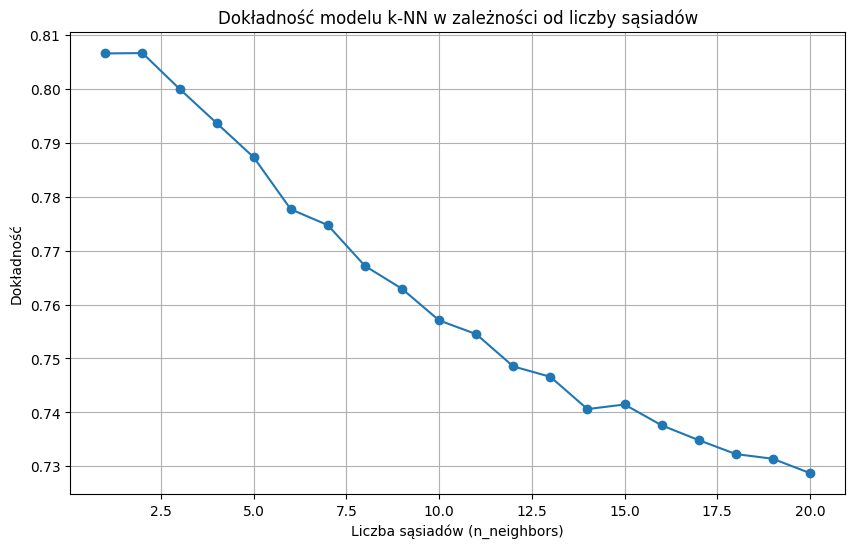

In [35]:
import matplotlib.pyplot as plt
# Przygotuj listy do przechowywania wyników
neighbors = range(1, 21)  # Testujemy od 1 do 20 sąsiadów
accuracies = []

# Testujemy różne wartości n_neighbors
for n in neighbors:
    print(f"Testujemy model z {n} sąsiadami")
    knn = KNeighborsClassifier(n_neighbors=n)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)


# Wyświetl wykres dokładności w zależności od liczby sąsiadów
plt.figure(figsize=(10, 6))
plt.plot(neighbors, accuracies, marker='o', linestyle='-')
plt.title('Dokładność modelu k-NN w zależności od liczby sąsiadów')
plt.xlabel('Liczba sąsiadów (n_neighbors)')
plt.ylabel('Dokładność')
plt.grid(True)
plt.show()

In [12]:
!pip install xgboost scikit-learn

/bin/bash: /home/miniyoda87/anaconda3/lib/libtinfo.so.6: no version information available (required by /bin/bash)
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com


In [17]:
import xgboost as xgb
from xgboost import DMatrix

def trenuj_xgboost(X_train, y_train, X_test, y_test, parametry=None):
    """
    Trenuje model XGBoost na danych treningowych i ocenia na danych testowych.

    Args:
    - X_train (array-like): cechy danych treningowych
    - y_train (array-like): etykiety danych treningowych
    - X_test (array-like): cechy danych testowych
    - y_test (array-like): etykiety danych testowych
    - parametry (dict, optional): parametry dla modelu XGBoost

    Returns:
    - model: wytrenowany model XGBoost
    - ocena: ocena modelu na danych testowych
    """

    if parametry is None:
        parametry = {
            'objective': 'binary:logistic',
            'eval_metric': 'logloss',
            'eta': 0.1,
            'max_depth': 5
        }

    dtrain = DMatrix(X_train, label=y_train)
    dtest = DMatrix(X_test, label=y_test)

    num_rounds = 100
    evals = [(dtrain, 'train'), (dtest, 'eval')]
    
    model = xgb.train(parametry, dtrain, num_rounds, evals, early_stopping_rounds=10, verbose_eval=True)
    
    ocena = model.eval(dtest)

    return model, ocena

# Przykład użycia (z przykładowymi danymi):
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

X, y = df[['Pora', 'Zachm3', \
       'Zachm6', 'ZachmN3', 'ZachmN6', 'Wiatr_N', 'Wiatr_E', 'Wiatr_S', \
       'Wiatr_W', 'DeltaTemp3', 'TemperaturaPowietrza', 'DeltaTemp6', \
       'DeltaTempRosy3', 'DeltaTempRosy6', 'TemperaturaPunktuRosy', \
       'Cisn3', 'Cisn6', 'CisnienieNaPoziomieStacji', 'Opady6', 'Opady12', \
       'Mgla6', 'Mzawka6', 'Deszcz6', 'Snieg6', 'Przelotny6', 'Burza6', \
       'Mgla_W', 'Mgla_E', 'Mgla_N', 'Mgla_S', 'Mzawka_W', 'Mzawka_E', \
       'Mzawka_N', 'Mzawka_S', 'Burza_W', 'Burza_E', 'Burza_N', 'Burza_S', \
       'Deszcz_W', 'Deszcz_E', 'Deszcz_N', 'Deszcz_S', 'Snieg_W', \
       'Snieg_E', 'Snieg_N', 'Snieg_S', 'OpadM_W', 'OpadM_E', 'OpadM_N', \
       'OpadM_S', 'Przelotny_W', 'Przelotny_E', 'Przelotny_N', \
       'Przelotny_S']], df.Pred6

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model, ocena = trenuj_xgboost(X_train, y_train, X_test, y_test)


c:\Users\Miniyoda87\.conda\envs\downgrade\lib\site-packages\xgboost\core.py:726: FutureWarning: Pass `evals` as keyword args.
  warnings.warn(msg, FutureWarning)


XGBoostError: [17:57:07] C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-07f6e447eee219473-1\xgboost\xgboost-ci-windows\src\objective\regression_obj.cu:144: label must be in [0,1] for logistic regression

1. Bagging: Random Forest

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

def train_random_forest(X_train, y_train):
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    return model

X, y = df[['Pora', 'Zachm3', \
       'Zachm6', 'ZachmN3', 'ZachmN6', 'Wiatr_N', 'Wiatr_E', 'Wiatr_S', \
       'Wiatr_W', 'DeltaTemp3', 'TemperaturaPowietrza', 'DeltaTemp6', \
       'DeltaTempRosy3', 'DeltaTempRosy6', 'TemperaturaPunktuRosy', \
       'Cisn3', 'Cisn6', 'CisnienieNaPoziomieStacji', 'Opady6', 'Opady12', \
       'Mgla6', 'Mzawka6', 'Deszcz6', 'Snieg6', 'Przelotny6', 'Burza6', \
       'Mgla_W', 'Mgla_E', 'Mgla_N', 'Mgla_S', 'Mzawka_W', 'Mzawka_E', \
       'Mzawka_N', 'Mzawka_S', 'Burza_W', 'Burza_E', 'Burza_N', 'Burza_S', \
       'Deszcz_W', 'Deszcz_E', 'Deszcz_N', 'Deszcz_S', 'Snieg_W', \
       'Snieg_E', 'Snieg_N', 'Snieg_S', 'OpadM_W', 'OpadM_E', 'OpadM_N', \
       'OpadM_S', 'Przelotny_W', 'Przelotny_E', 'Przelotny_N', \
       'Przelotny_S']], df.Pred6

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

train_random_forest(X_train, y_train)

RandomForestClassifier(random_state=42)

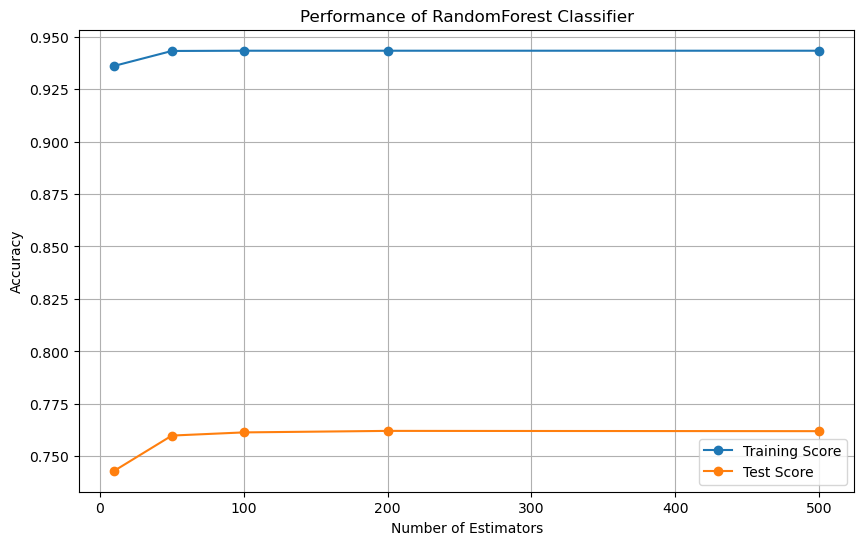

In [16]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Załaduj dane
X, y = df[['Pora', 'Zachm3', \
       'Zachm6', 'ZachmN3', 'ZachmN6', 'Wiatr_N', 'Wiatr_E', 'Wiatr_S', \
       'Wiatr_W', 'DeltaTemp3', 'TemperaturaPowietrza', 'DeltaTemp6', \
       'DeltaTempRosy3', 'DeltaTempRosy6', 'TemperaturaPunktuRosy', \
       'Cisn3', 'Cisn6', 'CisnienieNaPoziomieStacji', 'Opady6', 'Opady12', \
       'Mgla6', 'Mzawka6', 'Deszcz6', 'Snieg6', 'Przelotny6', 'Burza6', \
       'Mgla_W', 'Mgla_E', 'Mgla_N', 'Mgla_S', 'Mzawka_W', 'Mzawka_E', \
       'Mzawka_N', 'Mzawka_S', 'Burza_W', 'Burza_E', 'Burza_N', 'Burza_S', \
       'Deszcz_W', 'Deszcz_E', 'Deszcz_N', 'Deszcz_S', 'Snieg_W', \
       'Snieg_E', 'Snieg_N', 'Snieg_S', 'OpadM_W', 'OpadM_E', 'OpadM_N', \
       'OpadM_S', 'Przelotny_W', 'Przelotny_E', 'Przelotny_N', \
       'Przelotny_S']], df.Pred6

# Podziel dane
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

n_estimators_list = [10, 50, 100, 200, 500]
train_scores = []
test_scores = []

for n in n_estimators_list:
    # Trenuj model
    clf = RandomForestClassifier(n_estimators=n, random_state=42)
    clf.fit(X_train, y_train)
    
    # Zbierz wyniki
    train_scores.append(accuracy_score(y_train, clf.predict(X_train)))
    test_scores.append(accuracy_score(y_test, clf.predict(X_test)))

# Rysowanie wykresu
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_list, train_scores, label='Training Score', marker='o')
plt.plot(n_estimators_list, test_scores, label='Test Score', marker='o')
plt.xlabel('Number of Estimators')
plt.ylabel('Accuracy')
plt.title('Performance of RandomForest Classifier')
plt.legend()
plt.grid(True)
plt.show()


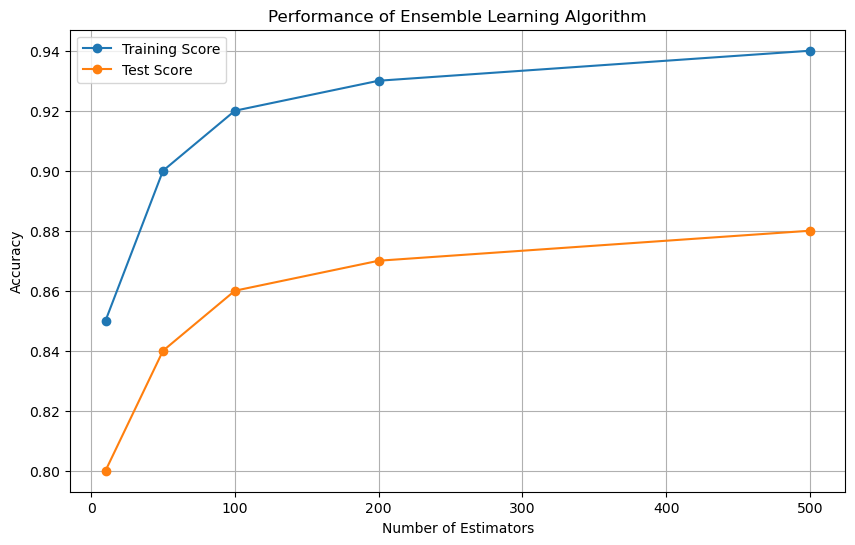

In [14]:
import matplotlib.pyplot as plt

# Przykładowe dane
n_estimators = [10, 50, 100, 200, 500]
train_scores = [0.85, 0.9, 0.92, 0.93, 0.94]
test_scores = [0.8, 0.84, 0.86, 0.87, 0.88]

# Rysowanie wykresu
plt.figure(figsize=(10, 6))
plt.plot(n_estimators, train_scores, label='Training Score', marker='o')
plt.plot(n_estimators, test_scores, label='Test Score', marker='o')
plt.xlabel('Number of Estimators')
plt.ylabel('Accuracy')
plt.title('Performance of Ensemble Learning Algorithm')
plt.legend()
plt.grid(True)
plt.show()


2. Boosting: AdaBoost

In [19]:
from sklearn.ensemble import AdaBoostClassifier

def train_adaboost(X_train, y_train):
    model = AdaBoostClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    return model

X, y = df[['Pora', 'Zachm3', \
       'Zachm6', 'ZachmN3', 'ZachmN6', 'Wiatr_N', 'Wiatr_E', 'Wiatr_S', \
       'Wiatr_W', 'DeltaTemp3', 'TemperaturaPowietrza', 'DeltaTemp6', \
       'DeltaTempRosy3', 'DeltaTempRosy6', 'TemperaturaPunktuRosy', \
       'Cisn3', 'Cisn6', 'CisnienieNaPoziomieStacji', 'Opady6', 'Opady12', \
       'Mgla6', 'Mzawka6', 'Deszcz6', 'Snieg6', 'Przelotny6', 'Burza6', \
       'Mgla_W', 'Mgla_E', 'Mgla_N', 'Mgla_S', 'Mzawka_W', 'Mzawka_E', \
       'Mzawka_N', 'Mzawka_S', 'Burza_W', 'Burza_E', 'Burza_N', 'Burza_S', \
       'Deszcz_W', 'Deszcz_E', 'Deszcz_N', 'Deszcz_S', 'Snieg_W', \
       'Snieg_E', 'Snieg_N', 'Snieg_S', 'OpadM_W', 'OpadM_E', 'OpadM_N', \
       'OpadM_S', 'Przelotny_W', 'Przelotny_E', 'Przelotny_N', \
       'Przelotny_S']], df.Pred6

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

train_adaboost(X_train, y_train)

AdaBoostClassifier(n_estimators=100, random_state=42)

3. Stacking

In [4]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

def train_stacking(X_train, y_train):
    estimators = [
        ('lr', LogisticRegression(max_iter=1000, random_state=42)),
        ('svc', SVC(probability=True, random_state=42)),
        ('gnb', GaussianNB())
    ]
    model = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(), cv=5)
    model.fit(X_train, y_train)
    return model

X, y = df[['Pora', 'Zachm3', \
       'Zachm6', 'ZachmN3', 'ZachmN6', 'Wiatr_N', 'Wiatr_E', 'Wiatr_S', \
       'Wiatr_W', 'DeltaTemp3', 'TemperaturaPowietrza', 'DeltaTemp6', \
       'DeltaTempRosy3', 'DeltaTempRosy6', 'TemperaturaPunktuRosy', \
       'Cisn3', 'Cisn6', 'CisnienieNaPoziomieStacji', 'Opady6', 'Opady12', \
       'Mgla6', 'Mzawka6', 'Deszcz6', 'Snieg6', 'Przelotny6', 'Burza6', \
       'Mgla_W', 'Mgla_E', 'Mgla_N', 'Mgla_S', 'Mzawka_W', 'Mzawka_E', \
       'Mzawka_N', 'Mzawka_S', 'Burza_W', 'Burza_E', 'Burza_N', 'Burza_S', \
       'Deszcz_W', 'Deszcz_E', 'Deszcz_N', 'Deszcz_S', 'Snieg_W', \
       'Snieg_E', 'Snieg_N', 'Snieg_S', 'OpadM_W', 'OpadM_E', 'OpadM_N', \
       'OpadM_S', 'Przelotny_W', 'Przelotny_E', 'Przelotny_N', \
       'Przelotny_S']], df.Pred6

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

train_stacking(X_train, y_train)

KeyboardInterrupt: 

In [1]:
from cuml.ensemble import StackingClassifier
from cuml.linear_model import LogisticRegression
from sklearn.svm import SVC  # cuml nie oferuje jeszcze wsparcia dla SVC
from cuml.naive_bayes import GaussianNB

def train_stacking(X_train, y_train):
    estimators = [
        ('lr', LogisticRegression(max_iter=1000)),
        ('svc', SVC(probability=True)),  # Używamy implementacji SVC z sklearn, ponieważ cuml nie oferuje wsparcia dla SVC
        ('gnb', GaussianNB())
    ]
    model = StackingClassifier(estimators=estimators, final_estimator=LogisticRegression(), cv=5)
    model.fit(X_train, y_train)
    return model

X, y = df[['Pora', 'Zachm3', \
       'Zachm6', 'ZachmN3', 'ZachmN6', 'Wiatr_N', 'Wiatr_E', 'Wiatr_S', \
       'Wiatr_W', 'DeltaTemp3', 'TemperaturaPowietrza', 'DeltaTemp6', \
       'DeltaTempRosy3', 'DeltaTempRosy6', 'TemperaturaPunktuRosy', \
       'Cisn3', 'Cisn6', 'CisnienieNaPoziomieStacji', 'Opady6', 'Opady12', \
       'Mgla6', 'Mzawka6', 'Deszcz6', 'Snieg6', 'Przelotny6', 'Burza6', \
       'Mgla_W', 'Mgla_E', 'Mgla_N', 'Mgla_S', 'Mzawka_W', 'Mzawka_E', \
       'Mzawka_N', 'Mzawka_S', 'Burza_W', 'Burza_E', 'Burza_N', 'Burza_S', \
       'Deszcz_W', 'Deszcz_E', 'Deszcz_N', 'Deszcz_S', 'Snieg_W', \
       'Snieg_E', 'Snieg_N', 'Snieg_S', 'OpadM_W', 'OpadM_E', 'OpadM_N', \
       'OpadM_S', 'Przelotny_W', 'Przelotny_E', 'Przelotny_N', \
       'Przelotny_S']], df.Pred6

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

train_stacking(X_train, y_train)


ImportError: cannot import name 'StackingClassifier' from 'cuml.ensemble' (/home/miniyoda87/anaconda3/envs/pytorch/rapids-23.10/lib/python3.9/site-packages/cuml/ensemble/__init__.py)

In [ ]:
def EksperymentMLRegresja(X,y):
    dfs=[]
    models = [
    ('LinReg', LinearRegression()), 
    ('RF', RandomForestRegressor()),
    ('Dtree', DecisionTreeRegressor()),
    ('lr', LogisticRegression(max_iter=1000)),
    ('svc', SVC(probability=True)),  # Używamy implementacji SVC z sklearn, ponieważ cuml nie oferuje wsparcia dla SVC
    ('gnb', GaussianNB())
    ],
    #wyniki=[]
    scoring=['neg_mean_absolute_error','r2']
    for nazwa,model in models:
        podzial=model_selection.KFold(n_splits=10,shuffle=True,random_state=125)
        cv_wynik=model_selection.cross_validate(model,X,y,cv=podzial,scoring=scoring)
        #wyniki.append(cv_wynik)
        df=pd.DataFrame(cv_wynik)
        df['model']=nazwa
        dfs.append(df)
    final=pd.concat(dfs,ignore_index=True)
    return final

In [ ]:
model = cuml.LinearRegression(fit_intercept=True, normalize=True)
model.fit(X_train, y_train).predict(X_test)

In [ ]:
model = cuml.Lasso(fit_intercept=False, normalize=True)
model.fit(X_train, y_train).predict(X_test)

In [ ]:
model = cuml.LogisticRegression(fit_intercept=True)
model.fit(X_train, y_train).predict(X_test)

In [ ]:
model.predict_proba(X_test)

In [ ]:
import matplotlib.pyplot as plt

# Przykładowe dane
n_estimators = [10, 50, 100, 200, 500]
train_scores = [0.85, 0.9, 0.92, 0.93, 0.94]
test_scores = [0.8, 0.84, 0.86, 0.87, 0.88]

# Rysowanie wykresu
plt.figure(figsize=(10, 6))
plt.plot(n_estimators, train_scores, label='Training Score', marker='o')
plt.plot(n_estimators, test_scores, label='Test Score', marker='o')
plt.xlabel('Number of Estimators')
plt.ylabel('Accuracy')
plt.title('Performance of Ensemble Learning Algorithm')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# import matplotlib.pyplot as plt

# # Indeksy wybranych cech (pierwsza i druga kolumna)
# feature1 = [0,  1,  3]
# feature2 = [0,  1,  3]

# # Indeksy klas (unikalne wartości w y)
# classes = list(set(y))

# # Kolor każdej klasy
# colors = ['b', 'g', 'r']

# # Tytuł wykresu
# plt.title("K-NN Classification")

# # Rysowanie punktów danych
# for c in classes:
#     plt.scatter(X_test[y_test == c, feature1], X_test[y_test == c, feature2], c=colors[c], label="Class " + str(c))

# # Rysowanie punktów predykcji
# plt.scatter(X_test[:, feature1], X_test[:, feature2], c='k', marker='x', label="Predictions")

# plt.xlabel('nr pomiaru')
# plt.ylabel('Predictions')

# plt.legend(loc='best')

# plt.show()


In [ ]:
# import matplotlib.pyplot as plt
# # Tworzenie wykresu dla predykcji kolejnych danych
# X_new = df[['id', 'Widz3']]

# # Przewidywanie klas na nowych danych
# y_new = knn.predict(X_new)

# print("Predykcje na nowych danych:")
# for i in range(len(X_new)):
#     print(f"Dane: {X_new[i]}, Predykcja klasy: {y_new[i]}")

# # Wykres klas
# plt.figure()
# plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=plt.cm.Set1, edgecolor='k')
# plt.xlabel('nr pomiaru')
# plt.ylabel('Predykcja widzialności na następne trzy godziny')

# plt.show()

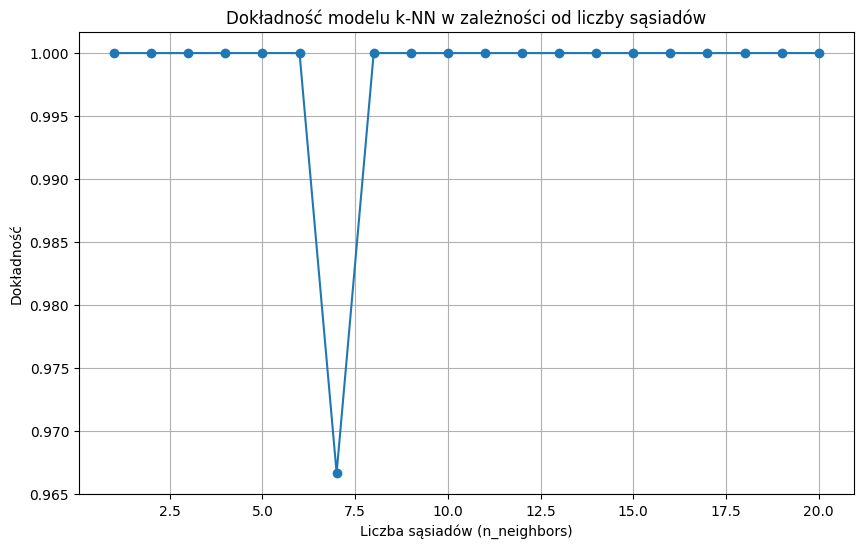

In [45]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Załaduj przykładowy zbiór danych (Iris dataset)
iris = load_iris()
X, y = iris.data, iris.target

# Podziel dane na zbiór treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Przygotuj listy do przechowywania wyników
neighbors = range(1, 21)  # Testujemy od 1 do 20 sąsiadów
accuracies = []

# Testujemy różne wartości n_neighbors
for n in neighbors:
    knn = KNeighborsClassifier(n_neighbors=n)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)

# Wyświetl wykres dokładności w zależności od liczby sąsiadów
plt.figure(figsize=(10, 6))
plt.plot(neighbors, accuracies, marker='o', linestyle='-')
plt.title('Dokładność modelu k-NN w zależności od liczby sąsiadów')
plt.xlabel('Liczba sąsiadów (n_neighbors)')
plt.ylabel('Dokładność')
plt.grid(True)
plt.show()


In [14]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.neighbors import NearestNeighbors

# Tworzenie przykładowych danych
X, y = df[['Pora', 'Zachm3', \
       'Zachm6', 'ZachmN3', 'ZachmN6', 'Wiatr_N', 'Wiatr_E', 'Wiatr_S', \
       'Wiatr_W', 'DeltaTemp3', 'TemperaturaPowietrza', 'DeltaTemp6', \
       'DeltaTempRosy3', 'DeltaTempRosy6', 'TemperaturaPunktuRosy', \
       'Cisn3', 'Cisn6', 'CisnienieNaPoziomieStacji', 'Opady6', 'Opady12', \
       'Mgla6', 'Mzawka6', 'Deszcz6', 'Snieg6', 'Przelotny6', 'Burza6', \
       'Mgla_W', 'Mgla_E', 'Mgla_N', 'Mgla_S', 'Mzawka_W', 'Mzawka_E', \
       'Mzawka_N', 'Mzawka_S', 'Burza_W', 'Burza_E', 'Burza_N', 'Burza_S', \
       'Deszcz_W', 'Deszcz_E', 'Deszcz_N', 'Deszcz_S', 'Snieg_W', \
       'Snieg_E', 'Snieg_N', 'Snieg_S', 'OpadM_W', 'OpadM_E', 'OpadM_N', \
       'OpadM_S', 'Przelotny_W', 'Przelotny_E', 'Przelotny_N', \
       'Przelotny_S']], df.Pred6

# Tworzenie modelu KNN
k = 3
knn = NearestNeighbors(n_neighbors=k)
knn.fit(X)

# Wykres
plt.figure(figsize=(8, 6))

# Wyznaczanie klastrów
distances, indices = knn.kneighbors(X)
for i in range(X.shape[0]):
    for j in indices[i]:
        plt.plot([X[i, 0], X[j, 0]], [X[i, 1], X[j, 1]], 'k--', alpha=0.3)

# Wyświetlenie punktów danych
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='viridis')
plt.title(f"KNN Clusters (k={k})")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


KeyError: (0, 0)

<Figure size 800x600 with 0 Axes>

In [6]:
!pip install nvitop

/bin/bash: /home/miniyoda87/anaconda3/lib/libtinfo.so.6: no version information available (required by /bin/bash)
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
  Obtaining dependency information for nvitop from https://files.pythonhosted.org/packages/c3/79/a26b04da3a3f2bf52b793078f4478fcea5b55f9be88d45127c7c85d59f94/nvitop-1.3.1-py3-none-any.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 2.3 MB/s eta 0:00:00
  Obtaining dependency information for nvidia-ml-py<12.536.0a0,>=11.450.51 from https://files.pythonhosted.org/packages/08/4e/f0d9ea02ab4c0bfa37f7753c31ffaddf248fa3d35b1c60f5626776c52afb/nvidia_ml_py-12.535.108-py3-none-any.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.4/213.4 kB 8.3 MB/s eta 0:00:00


In [6]:
!python3 -c "import tensorflow as tf; print(tf.config.list_physical_devices('GPU'))"

/bin/bash: /home/miniyoda87/anaconda3/lib/libtinfo.so.6: no version information available (required by /bin/bash)
Traceback (most recent call last):
  File "<string>", line 1, in <module>
ModuleNotFoundError: No module named 'tensorflow'


In [7]:
!nvidia-smi

/bin/bash: /home/miniyoda87/anaconda3/lib/libtinfo.so.6: no version information available (required by /bin/bash)
Wed Oct 25 22:51:45 2023       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.113.01             Driver Version: 535.113.01   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA GeForce RTX 4090        Off | 00000000:01:00.0  On |                  Off |
|  0%   53C    P0              46W / 450W |   2591MiB / 24564MiB |     11%      Default |
|                                         | 

In [8]:
!python -m nvitop

/bin/bash: /home/miniyoda87/anaconda3/lib/libtinfo.so.6: no version information available (required by /bin/bash)
/home/miniyoda87/anaconda3/envs/pytorch/rapids-23.10/bin/python: No module named nvitop
